# 01 — Data Understanding (EDA)

**Чекпоінт:** Data understanding (0.50 бала).

**Мета ноутбука** — не показати всі можливі графіки, а знайти ті властивості даних,
які визначають подальші рішення в пайплайні. Під кожним графіком стоїть висновок;
останній розділ зводить їх у список «спостереження → рішення».

**Важливо щодо даних.** Весь аналіз виконується **тільки на `train_dev`** (396 900 рядків,
90% від `train.csv`). Решта 10% (`holdout.parquet`, 44 100 рядків) відрізані в
`src/data.py` **до** цього ноутбука і не читаються тут. Причина: holdout має залишитись
повністю незалежною оцінкою для фіналу, а якби ми дивилися на його розподіли й викиди,
наші рішення щодо препроцесингу частково спиралися б на нього.

Нормалізація категорій (`strip` + `lower`) уже застосована в `src/data.py`, бо це
детермінована операція без навчання. Усі **навчені** перетворення (імпутація, скейлінг,
енкодинг) залишені на етап моделювання і живуть всередині фолдів.

In [1]:
import sys, warnings
sys.path.insert(0, '../src')
warnings.filterwarnings('ignore', category=FutureWarning)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import config as C
import data as D
import viz

viz.set_style()
pd.set_option('display.width', 120)
pd.set_option('display.max_columns', 30)

train = D.load_train_dev()      # 90% train.csv — holdout НЕ читаємо
test   = D.load_test()
print(f'train_dev: {train.shape}   test: {test.shape}')

train_dev: (396900, 17)   test: (189000, 16)


## 1. Огляд: типи, пропуски, кардинальність

Одна таблиця замість десятка окремих принтів. Вона одразу закриває три вимоги
чекпоінта: типи фіч, пропуски, і перший погляд на потенційну редундантність.

In [2]:
def overview(df, name):
    return pd.DataFrame({
        'dtype': df.dtypes.astype(str),
        'n_missing': df.isna().sum(),
        'pct_missing': (df.isna().mean() * 100).round(2),
        'n_unique': df.nunique(),
        'example': [df[c].dropna().iloc[0] if df[c].notna().any() else None for c in df.columns],
    }).rename_axis(name)

ov = overview(train, 'train_dev')
ov

,dtype,n_missing,pct_missing,n_unique,example
train_dev,,,,,
record_id,int64,0,0.00,396900,1300896
learner_age,float64,11850,2.99,8,18.0
gender_group,category,7995,2.01,3,other
program_track,category,8085,2.04,7,b.sc
study_time,float64,12737,3.21,1290,0.94
attendance_rate,float64,11963,3.01,1044,70.0
home_internet,category,7896,1.99,2,yes
sleep_duration,float64,11804,2.97,634,6.56
rest_quality,category,7893,1.99,3,average


**Висновок.** 15 фіч + `record_id` + таргет. Сім числових, вісім категоріальних.
Пропуски присутні **в кожній** фічі: 2.97–3.21% у числових, 1.99–2.04% у категоріальних.
`record_id` унікальний — це ідентифікатор, у фічі не йде (зафіксовано явним
списком `C.FEATURES_V0`).

Кардинальність категорій низька (2–12), тож one-hot кодування цілком придатне і
target encoding не потрібен — він лише додав би ризик витоку без виграшу.

Дві аномалії кардинальності серед числових фіч варто відмітити зараз, вони знадобляться далі:
- `learner_age` має лише **8** унікальних значень (17–24) — фактично це порядкова, а не
  неперервна змінна;
- `intake_marker` має **319 732** унікальних значення на 396 900 рядків, тобто майже
  унікальне число в кожному рядку. Така кардинальність сама по собі підозріла і
  пояснить поведінку цієї фічі в §8.

In [3]:
# Чи однакова структура пропусків у train і test? Якби вона відрізнялась,
# імпутація, навчена на train, систематично зсувала б прогнози на test.
cmp_na = pd.DataFrame({
    'train_dev_%': (train[C.FEATURES_V0].isna().mean() * 100).round(2),
    'test_%':      (test[C.FEATURES_V0].isna().mean() * 100).round(2),
})
cmp_na['різниця'] = (cmp_na['test_%'] - cmp_na['train_dev_%']).round(2)
cmp_na.sort_values('різниця', key=abs, ascending=False)

,train_dev_%,test_%,різниця
learner_age,2.99,3.11,0.12
engagement_index,3.02,3.10,0.08
intake_marker,2.98,3.06,0.08
sleep_duration,2.97,3.03,0.06
study_time,3.21,3.26,0.05
program_track,2.04,2.09,0.05
study_minutes,2.98,2.94,-0.04
campus_resources,2.02,1.98,-0.04
assessment_level,2.01,1.97,-0.04
gender_group,2.01,2.04,0.03


**Висновок.** Максимальна різниця в частці пропусків між train і test — 0.1 відсоткового
пункту. Механізм пропусків однаковий, отже імпутер, навчений на train, коректно
переноситься на test.

## 2. Розподіл таргета

Від форми розподілу залежить, чи потрібна трансформація таргета і чи RMSE —
адекватна метрика.

In [4]:
y = train[C.TARGET]
print(y.describe().round(3).to_string())
print(f"\nунікальних значень: {y.nunique()}   skewness: {y.skew():.3f}   kurtosis: {y.kurtosis():.3f}")
print(f"RMSE константного прогнозу (= std таргета): {y.std():.4f}")

count    396900.000
mean         62.514
std          18.918
min          19.599
25%          48.800
50%          62.600
75%          76.300
max         100.000

унікальних значень: 805   skewness: -0.049   kurtosis: -0.618
RMSE константного прогнозу (= std таргета): 18.9183


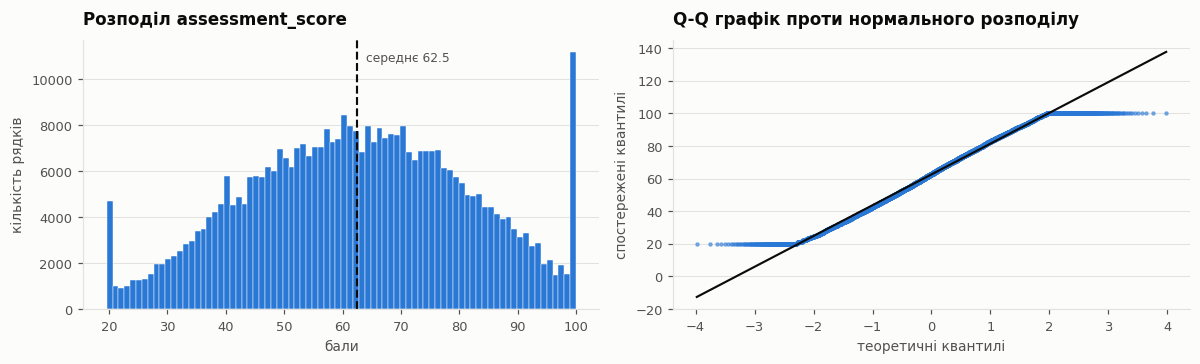

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.4))

ax = axes[0]
ax.hist(y, bins=80, color=viz.BLUE, edgecolor=viz.SURFACE, linewidth=0.3)
ax.axvline(y.mean(), color=viz.INK, linewidth=1.4, linestyle='--')
ax.text(y.mean() + 1.5, ax.get_ylim()[1] * 0.92, f'середнє {y.mean():.1f}',
        fontsize=8, color=viz.INK_SECONDARY)
ax.set_title('Розподіл assessment_score')
ax.set_xlabel('бали'); ax.set_ylabel('кількість рядків')

ax = axes[1]
from scipy import stats
stats.probplot(y.sample(20000, random_state=C.SEED), dist='norm', plot=ax)
ax.get_lines()[0].set(color=viz.BLUE, markersize=2, alpha=0.5)
ax.get_lines()[1].set(color=viz.INK, linewidth=1.4)
ax.set_title('Q-Q графік проти нормального розподілу')
ax.set_xlabel('теоретичні квантилі'); ax.set_ylabel('спостережені квантилі')

plt.tight_layout(); plt.show()

In [6]:

# Піки на кінцях гістограми — це точкові маси, а не хвости. Квантифікуємо.
lo, hi = y.min(), y.max()
print(f'діапазон таргета: [{lo}, {hi}]')
print(f'  рівно {hi} (стеля):   {(y == hi).sum():5d} рядків = {(y == hi).mean() * 100:.2f}%')
print(f'  рівно {lo} (підлога): {(y == lo).sum():5d} рядків = {(y == lo).mean() * 100:.2f}%')
print(f'  разом на межах:      {((y == hi) | (y == lo)).mean() * 100:.2f}%')
print(f'\nдля порівняння, сусідні інтервали тієї ж ширини:')
print(f'  (99, 100)      : {((y > 99) & (y < hi)).sum():5d}')
print(f'  (19.599, 20.6) : {((y > lo) & (y < 20.6)).sum():5d}')


діапазон таргета: [19.599, 100.0]
  рівно 100.0 (стеля):    9749 рядків = 2.46%
  рівно 19.599 (підлога):  3988 рядків = 1.00%
  разом на межах:      3.46%

для порівняння, сусідні інтервали тієї ж ширини:
  (99, 100)      :  1251
  (19.599, 20.6) :   664


**Висновок.** Розподіл майже симетричний (skewness = −0.049), без важких хвостів
(kurtosis = −0.618). Але гістограма показує головне: **два різкі піки на кінцях**.

Це не хвости розподілу, а **точкові маси**: рівно 100.0 мають 2.46% рядків, рівно
19.599 — ще 1.00%, разом 3.46%. Сусідні інтервали тієї ж ширини містять у рази менше
рядків. Q-Q графік підтверджує це двома плоскими горизонтальними ділянками на кінцях.

Отже таргет **цензурований**: справжнє значення обрізали до [19.599, 100], і все, що
виходило за межі, склалося в ці дві точки.

Наслідки:
1. **Лог-трансформація таргета не потрібна** — вона лікує праву асиметрію, якої тут немає.
   Оптимізуємо RMSE напряму.
2. **RMSE константного прогнозу = стандартне відхилення таргета = 18.9183.**
   Точка відліку: будь-яка модель мусить бути краще за це число.
3. **Клампінг прогнозів обов'язковий, і межі — спостережені, а не [0, 100].**
   Перевірка на сабмішні кроку 0: лінійна регресія, кліпнута у [0, 100], дала 92 прогнози
   нижче 19.599 — кожен із них гарантовано гірший за просте 19.599, бо таких значень
   у даних не існує. Правильні межі — `[19.599, 100.0]` з train. Ефект малий (0.05%
   рядків), але безкоштовний.
4. Цензурування ставить **стелю на досяжну якість**: 3.46% рядків мають значення, яке
   гладка функція від фіч не може відтворити точно. Це одна з причин, чому RMSE ≈ 8.9
   виявиться важко покращити. Як ідея для ноутбука 04 — двоетапна схема (класифікатор
   «чи рядок на межі» + регресор), але очікування скромні.

## 3. Пропуски: чи вони щось говорять про таргет?

Питання не «скільки пропусків», а **чи сам факт пропуску пов'язаний з таргетом**.
Відповідь визначає, чи має сенс додавати missing-індикатори як фічі.

Якщо дані пропущені повністю випадково (MCAR), середній таргет серед рядків із
пропуском дорівнюватиме глобальному середньому, і індикатор пропуску не нестиме
інформації. Щоб відрізнити реальну різницю від шуму, рахуємо стандартну помилку:
SE = σ / √n, де n — кількість рядків із пропуском.

In [7]:
rows = []
for c in C.FEATURES_V0:
    na = train[c].isna()
    n_na = int(na.sum())
    m_na, m_ok = y[na].mean(), y[~na].mean()
    se = y.std() / np.sqrt(n_na)          # SE середнього в групі з пропуском
    diff = m_na - m_ok
    rows.append({
        'фіча': c, 'n_na': n_na,
        'mean_target_NaN': round(m_na, 3),
        'mean_target_ok': round(m_ok, 3),
        'різниця': round(diff, 3),
        'SE': round(se, 3),
        'z = різниця/SE': round(diff / se, 2),
    })
mcar = pd.DataFrame(rows).sort_values('z = різниця/SE', key=abs, ascending=False)
mcar

,фіча,n_na,mean_target_NaN,mean_target_ok,різниця,SE,z = різниця/SE
0,learner_age,11850,62.202,62.523,-0.321,0.174,-1.85
3,sleep_duration,11804,62.218,62.523,-0.305,0.174,-1.75
13,assessment_level,7977,62.233,62.519,-0.286,0.212,-1.35
8,program_track,8085,62.771,62.508,0.263,0.210,1.25
9,home_internet,7896,62.754,62.509,0.246,0.213,1.15
1,study_time,12737,62.371,62.518,-0.148,0.168,-0.88
14,registration_group,7951,62.694,62.510,0.184,0.212,0.87
6,intake_marker,11811,62.381,62.518,-0.136,0.174,-0.78
4,study_minutes,11830,62.405,62.517,-0.112,0.174,-0.65
12,campus_resources,8021,62.555,62.513,0.042,0.211,0.20


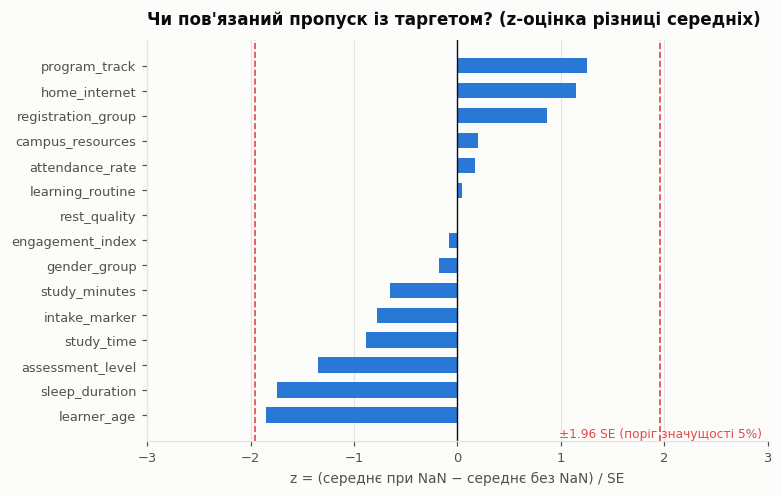

In [8]:
fig, ax = plt.subplots(figsize=(7.2, 4.6))
d = mcar.sort_values('z = різниця/SE')
ax.barh(d['фіча'], d['z = різниця/SE'], color=viz.BLUE, height=0.62)
for x in (-1.96, 1.96):
    ax.axvline(x, color=viz.RED, linewidth=1.1, linestyle='--')
ax.axvline(0, color=viz.INK, linewidth=0.9)
ax.text(1.96, -0.9, '±1.96 SE (поріг значущості 5%)', fontsize=8, color=viz.RED, ha='center')
ax.set_title('Чи пов\'язаний пропуск із таргетом? (z-оцінка різниці середніх)')
ax.set_xlabel('z = (середнє при NaN − середнє без NaN) / SE')
ax.grid(axis='x'); ax.grid(axis='y', visible=False)
ax.set_xlim(-3, 3)
plt.tight_layout(); plt.show()

**Висновок.** Жодна фіча не виходить за межі ±1.96 SE: найбільше за модулем значення —
`learner_age` з z = −1.85. Це саме те, що очікується під нульовою гіпотезою: при
15 незалежних перевірках максимальний |z| типово становить ≈ 2.1, тому одне значення
біля 1.85 не є свідченням зв'язку. Пропуски **MCAR** (missing completely at random):
факт пропуску не несе інформації про таргет.

**Передбачення для §Feature Engineering:** missing-індикатори (`*_isna`) не дадуть
покращення. Це передбачення перевіряється експериментом FE-3 у ноутбуці 03 —
і саме така послідовність («EDA передбачив → експеримент підтвердив») є тим,
що вимагається від цього чекпоінта.

Практичний наслідок для препроцесингу: пропуски можна просто імпутувати
(median / most_frequent) без спроб моделювати механізм їх виникнення.

In [9]:
# Чи пропуски вносились незалежно по колонках? Якщо так, кількість пропусків
# у рядку має підкорятися біноміальному розподілу, а не концентруватися.
n_missing_row = train[C.FEATURES_V0].isna().sum(axis=1)
obs = n_missing_row.value_counts().sort_index()
# очікуване при незалежності: сума 15 незалежних індикаторів з власними p
p = train[C.FEATURES_V0].isna().mean().values
exp_mean = p.sum()
print('Кількість пропусків у рядку:')
print(pd.DataFrame({'спостережено': obs, 'частка_%': (obs / len(train) * 100).round(2)}).head(7).to_string())
print(f'\nсереднє спостережене {n_missing_row.mean():.4f}  vs  сума p_i = {exp_mean:.4f}')
print(f'дисперсія спостережена {n_missing_row.var():.4f}  vs  сума p_i(1-p_i) = {(p*(1-p)).sum():.4f}')

Кількість пропусків у рядку:
   спостережено  частка_%
0        272027     68.54
1        104336     26.29
2         18355      4.62
3          2024      0.51
4           151      0.04
5             7      0.00

середнє спостережене 0.3723  vs  сума p_i = 0.3723
дисперсія спостережена 0.3617  vs  сума p_i(1-p_i) = 0.3627


**Висновок.** Середнє і дисперсія кількості пропусків у рядку майже точно
збігаються з теоретичними значеннями для **незалежних** індикаторів
(Σp vs Σp(1−p)). Пропуски вносились по кожній колонці незалежно — підтверджує MCAR
і означає, що агрегована фіча `n_missing` теж має бути неінформативною.

## 4. Категоріальні фічі та неузгодженість значень

`src/data.py` уже нормалізував категорії, тому тут ми спершу читаємо **сирий**
`train.csv`, щоб показати, яку саме проблему ця нормалізація вирішує. Сирі дані
обмежуємо тими ж `record_id`, що й у `train_dev` — щоб навіть на цьому кроці не
зазирати в holdout.

In [10]:
raw = pd.read_csv(C.RAW_TRAIN)
raw = raw[raw[C.ID_COL].isin(set(train[C.ID_COL]))]   # ті самі рядки, що в train_dev
print(f'сирий train_dev: {raw.shape}')

# Скільки окремих значень бачить модель ДО і ПІСЛЯ нормалізації
comp = pd.DataFrame({
    'до_нормалізації': raw[C.CAT_COLS].nunique(),
    'після': train[C.CAT_COLS].nunique(),
})
comp['зайвих_рівнів'] = comp['до_нормалізації'] - comp['після']
comp

сирий train_dev: (396900, 17)


,до_нормалізації,після,зайвих_рівнів
gender_group,3,3,0
program_track,14,7,7
home_internet,2,2,0
rest_quality,6,3,3
learning_routine,10,5,5
campus_resources,3,3,0
assessment_level,3,3,0
registration_group,12,12,0


In [11]:
# Які саме значення були "брудними"
dirty = {}
for c in C.CAT_COLS:
    vc = raw[c].value_counts(dropna=False)
    bad = [v for v in vc.index if isinstance(v, str) and (v != v.strip() or v != v.lower())]
    if bad:
        dirty[c] = vc[bad]
for c, s in dirty.items():
    print(f'\n{c}:')
    print(s.to_string())


program_track:
program_track
B.TECH      1290
B.SC        1038
B.COM        998
BCA          781
BBA          676
BA           590
DIPLOMA      452

rest_quality:
rest_quality
POOR        1988
GOOD        1950
AVERAGE     1888

learning_routine:
learning_routine
SELF-STUDY        1259
COACHING          1205
ONLINE VIDEOS     1199
GROUP STUDY       1178
MIXED             1141

registration_group:
registration_group
G10    32632
G08    32624
G05    32596
G07    32560
G11    32510
G12    32452
G02    32451
G03    32331
G04    32298
G01    32262
G06    32229
G09    32004


**Висновок.** Три фічі (`program_track`, `rest_quality`, `learning_routine`) містять
«брудних двійників»: ті самі категорії з ведучим пробілом і у ВЕРХНЬОМУ регістрі,
приблизно 1.5% рядків кожної.

Чому це обов'язково виправити **до** моделювання:
- `OneHotEncoder` створив би окремі колонки для `'b.tech'` і `' B.TECH'`, роздувши
  простір фіч дублікатами;
- дерево розщепило б одну й ту саму категорію на дві гілки, у кожній — менше
  прикладів, отже шумніша оцінка в листі.

Нормалізація `strip` + `lower` — **детермінована** операція: кожен рядок
обробляється незалежно, жодна статистика з даних не оцінюється. Тому вона
безпечно виконується один раз до розрізання на фолди і не створює витоку.

In [12]:
# Ключова додаткова перевірка: чи "брудність" рядка сама по собі пов'язана з таргетом?
# Якщо дані псувались невипадково, прапорець "рядок був брудний" був би реальною фічею.

def dirty_twin_mask(s: pd.Series) -> pd.Series:
    """Позначає значення, чия нормалізована форма ТАКОЖ присутня в колонці окремо.

    Наївна перевірка (s != s.str.lower()) хибна: вона позначила б усі значення
    registration_group (G01..G12), де верхній регістр — канонічний формат, а не
    помилка, і жодних дублікатів не створюється. Нас цікавлять лише справжні
    двійники: ' B.TECH' при наявному 'b.tech'.
    """
    present = set(s.dropna().unique())
    norm = s.str.strip().str.lower()
    return s.notna() & (s != norm) & norm.isin(present)

raw_y = raw[C.TARGET]
masks, rows = {}, []
for c in C.CAT_COLS:
    m = dirty_twin_mask(raw[c])
    if m.sum() == 0:
        continue
    masks[c] = m
    m_d, m_c = raw_y[m].mean(), raw_y[~m & raw[c].notna()].mean()
    se = raw_y.std() / np.sqrt(m.sum())
    rows.append({'фіча': c, 'n_двійників': int(m.sum()),
                 'mean_target_брудні': round(m_d, 3), 'mean_target_чисті': round(m_c, 3),
                 'різниця': round(m_d - m_c, 3), 'SE': round(se, 3),
                 'z': round((m_d - m_c) / se, 2)})

any_dirty = pd.concat(masks.values(), axis=1).any(axis=1)
m_d, m_c = raw_y[any_dirty].mean(), raw_y[~any_dirty].mean()
se = raw_y.std() / np.sqrt(any_dirty.sum())
rows.append({'фіча': 'ЛЮБА з трьох колонок', 'n_двійників': int(any_dirty.sum()),
             'mean_target_брудні': round(m_d, 3), 'mean_target_чисті': round(m_c, 3),
             'різниця': round(m_d - m_c, 3), 'SE': round(se, 3), 'z': round((m_d - m_c) / se, 2)})

from scipy.stats import norm as _norm
n_tests = len(rows) - 1
print(f'Перевірок: {n_tests}.  Поріг Бонферроні для 5%: |z| > {abs(_norm.ppf(0.025 / n_tests)):.2f}')
pd.DataFrame(rows)

Перевірок: 3.  Поріг Бонферроні для 5%: |z| > 2.39


,фіча,n_двійників,mean_target_брудні,mean_target_чисті,різниця,SE,z
0,program_track,5825,62.816,62.504,0.313,0.248,1.26
1,rest_quality,5826,62.365,62.516,-0.151,0.248,-0.61
2,learning_routine,5982,61.920,62.523,-0.602,0.245,-2.46
3,ЛЮБА з трьох колонок,17385,62.362,62.521,-0.159,0.143,-1.11


**Висновок.** Три колонки мають справжніх двійників, по ~5 800–6 000 рядків кожна
(17 385 унікальних рядків разом). Результати:

| фіча | n двійників | різниця середніх | z |
|---|---:|---:|---:|
| `program_track` | 5 825 | +0.313 | +1.26 |
| `rest_quality` | 5 826 | −0.151 | −0.61 |
| `learning_routine` | 5 982 | **−0.602** | **−2.46** |
| будь-яка з трьох | 17 385 | −0.159 | −1.11 |

Два випадки — чистий шум. `learning_routine` з z = −2.46 **формально перевищує** поріг
Бонферроні для трьох перевірок (|z| > 2.39), тож статистично це гранично значущий
результат, і неправильно було б оголосити його шумом.

Але розмір ефекту робить його непридатним до використання: **0.6 бала** при σ таргета
18.9 і RMSE найкращої моделі ≈ 8.9. Навіть якби зв'язок був справжнім, фіча такої сили
не змінила б прогноз помітно. До того ж агрегат по всіх трьох колонках (z = −1.11)
сигналу не показує — а якби псування даних справді корелювало з таргетом, ефект мав би
проявитися і в агрегаті.

**Рішення.** Нормалізацію застосовуємо (вона потрібна незалежно від цього результату —
див. нижче). Прапорець «рядок був брудний» у базовий фіче-сет **не** додаємо, але
фіксуємо як гіпотезу з граничною значущістю; якщо в ноутбуці 03 залишиться бюджет,
це дешева перевірка на одну колонку. Передбачення — нульовий ефект через розмір.

Чому нормалізація обов'язкова незалежно від цього:
- `OneHotEncoder` створив би окремі колонки для `'b.tech'` і `' B.TECH'`, роздувши
  простір фіч дублікатами;
- дерево розщепило б одну й ту саму категорію на дві гілки, у кожній — менше
  прикладів, отже шумніша оцінка в листі.

*Методична примітка.* Перший варіант цієї перевірки використовував наївний критерій
`s != s.str.lower()` і позначив як «брудні» всі 389 000 рядків `registration_group`,
бо там верхній регістр (`G01`…`G12`) — канонічний формат, а не помилка. Агрегат тоді
дав фальшиве z = −6.84, тобто «дуже значущий» результат з нуля. Правильний критерій —
**двійник**: значення, чия нормалізована форма присутня в колонці як окреме значення.
Це ілюстрація того, чому результат автоматичної перевірки треба зіставляти зі змістом
даних, а не приймати на віру.

In [13]:
# Чи є в test категорії, яких немає в train? Від цього страхує handle_unknown='ignore'.
for c in C.CAT_COLS:
    tr_lv, te_lv = set(train[c].dropna().unique()), set(test[c].dropna().unique())
    only_te, only_tr = te_lv - tr_lv, tr_lv - te_lv
    flag = 'OK' if not (only_te or only_tr) else f'тільки в test: {only_te} | тільки в train: {only_tr}'
    print(f'{c:20s} {len(tr_lv):2d} рівнів  {flag}')

gender_group          3 рівнів  OK
program_track         7 рівнів  OK
home_internet         2 рівнів  OK
rest_quality          3 рівнів  OK
learning_routine      5 рівнів  OK
campus_resources      3 рівнів  OK
assessment_level      3 рівнів  OK
registration_group   12 рівнів  OK


**Висновок.** Множини категорій у train і test ідентичні — нових значень на test не буде.
`handle_unknown='ignore'` усе одно залишаємо в препроцесорі: всередині CV навчальний
фолд — це лише 80% даних, і там рідкісна категорія теоретично може не трапитись.

## 5. Числові фічі: розподіли та значення поза фізичними межами

Межі задані в `C.PHYSICAL_BOUNDS` **з предметної логіки**, а не з даних
(відвідуваність — відсоток, отже ≤ 100; `study_minutes` має стелю 528 хв ≈ 8.8 год).
Це важливо: оскільку межа взята з домену, застосування `clip()` на її основі не є
навченою операцією і не створює витоку.

In [14]:
desc = train[C.NUM_COLS].describe().T[['count', 'mean', 'std', 'min', '50%', 'max']].round(3)
viol = []
for c in C.NUM_COLS:
    lo, hi = C.PHYSICAL_BOUNDS[c]
    n_lo = int((train[c] < lo).sum()); n_hi = int((train[c] > hi).sum())
    viol.append({'межі': f'[{lo:g}, {hi:g}]', 'нижче': n_lo, 'вище': n_hi,
                 'разом_%': round((n_lo + n_hi) / len(train) * 100, 3),
                 'нулів': int((train[c] == 0).sum())})
pd.concat([desc, pd.DataFrame(viol, index=C.NUM_COLS)], axis=1)

,count,mean,std,min,50%,max,межі,нижче,вище,разом_%,нулів
learner_age,385050.0,20.546,2.259,17.00,21.000,24.00,"[10, 100]",0,0,0.000,0
study_time,384163.0,4.040,2.506,0.00,4.010,32.24,"[0, 9]",0,849,0.214,1860
attendance_rate,384937.0,72.109,17.587,38.70,72.600,150.00,"[0, 100]",0,682,0.172,0
sleep_duration,385096.0,7.073,1.746,3.85,7.110,10.18,"[0, 24]",0,0,0.000,0
study_minutes,385070.0,240.268,142.046,0.00,239.900,528.00,"[0, 540]",0,0,0.000,5291
engagement_index,384929.0,64.320,16.283,16.41,64.500,110.87,"[0, 100]",0,1328,0.335,0
intake_marker,385089.0,0.500,0.289,0.00,0.501,1.00,"[0, 1]",0,0,0.000,0


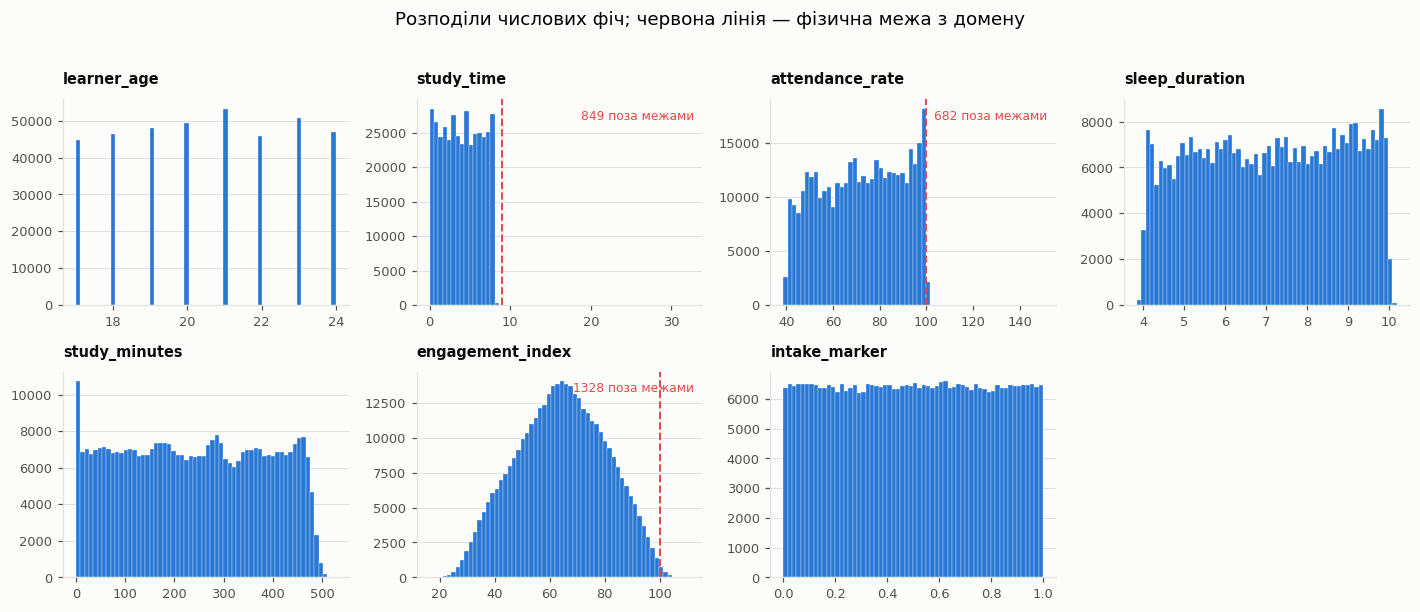

In [15]:
fig, axes = plt.subplots(2, 4, figsize=(13, 5.4))
for ax, c in zip(axes.ravel(), C.NUM_COLS):
    lo, hi = C.PHYSICAL_BOUNDS[c]
    s = train[c].dropna()
    ax.hist(s, bins=60, color=viz.BLUE, edgecolor=viz.SURFACE, linewidth=0.2)
    n_out = int(((s < lo) | (s > hi)).sum())
    if n_out:
        ax.axvline(hi, color=viz.RED, linewidth=1.3, linestyle='--')
        ax.text(0.97, 0.9, f'{n_out} поза межами', transform=ax.transAxes, ha='right',
                fontsize=8, color=viz.RED)
    ax.set_title(c, fontsize=9.5)
    ax.set_ylabel('')
axes.ravel()[-1].axis('off')
fig.suptitle('Розподіли числових фіч; червона лінія — фізична межа з домену', y=1.02)
plt.tight_layout(); plt.show()

**Висновок.** Порушення фізичних меж є у трьох фічах:

| фіча | порушень | % рядків | max | коментар |
|---|---:|---:|---:|---|
| `engagement_index` | 1 328 | 0.335 | 110.87 | індекс виходить за 100 |
| `study_time` | 849 | 0.214 | 32.24 | 32 години навчання на добу неможливі |
| `attendance_rate` | 682 | 0.172 | 150.00 | відвідуваність > 100% неможлива |

Решта фіч лежать у розумних межах: `learner_age` 17–24, `sleep_duration` 3.85–10.18,
`study_minutes` 0–528, `intake_marker` 0–1.

`intake_marker` має підозріло **рівномірний** розподіл на [0, 1] (середнє 0.500,
медіана 0.501) — разом із майже унікальним значенням у кожному рядку (§1) це типова
ознака штучно згенерованого шуму. Перевіряємо в §7.

Нулі: `study_time` = 0 у 1 860 рядках, `study_minutes` = 0 у 5 291. Це правдоподібні
значення (студент не вчився), тому як викиди їх не трактуємо. Розбіжність між цими
двома числами, до речі, — ще один натяк на те, що фічі не є точним дублікатом; див. §6.

**Рішення:** викиди не видаляємо (це 0.17–0.34% даних і вони є також у test), але
клампінг до фізичних меж перевіряємо як окрему зміну фіч у ноутбуці 03. Очікування:
для дерев ефект ~нуль (клампінг — монотонне перетворення, не змінює порядок, отже не
змінює можливі спліти), для лінійної регресії — помітний, бо викид у 150 при σ = 17.6
працює як важіль.

**Окремо — форма самих розподілів, вона промовиста.**

`learner_age`, `study_time`, `study_minutes`, `sleep_duration`, `intake_marker` розподілені
**рівномірно** (плоскі гістограми), `attendance_rate` — майже рівномірно зі зростанням.
Рівномірні розподіли в реальних даних про людей не трапляються: вік студентів мав би мати
моду, час сну — дзвін навколо 7 годин. Це **згенеровані дані**, і фічі насемплені незалежно
з рівномірних розподілів.

Виняток один і він важливий: **`engagement_index` має чітко дзвоноподібну форму.** Сума
кількох незалежних рівномірних величин дає дзвін за центральною граничною теоремою — отже
сама форма розподілу підказує, що ця фіча не насемплена, а **обчислена з інших**.
Перевіряємо гіпотезу в §7.1.

Ще дві деталі: `study_minutes` має пік на 0 і різкий обрив на 528 (фізична стеля з §6),
а `attendance_rate` — пік рівно на 100, тобто цензурована так само, як і таргет (§2).

## 6. `study_time` vs `study_minutes` — найважливіша знахідка

Дві фічі описують одне й те саме: час навчання в годинах і в хвилинах.
Питання — чи це точний дублікат, і якщо ні, то яка з версій надійніша.

In [16]:
d = train[['study_time', 'study_minutes', C.TARGET]].dropna(subset=['study_time', 'study_minutes'])
resid = d.study_minutes - 60 * d.study_time

print(f'корелація study_time ~ study_minutes: {d.study_time.corr(d.study_minutes):.5f}')
print(f'\nзалишок (study_minutes - 60*study_time):')
print(resid.describe().round(2).to_string())
print(f'\nmax study_time = {train.study_time.max():.2f} год')
print(f'max study_minutes = {train.study_minutes.max():.1f} хв = {train.study_minutes.max()/60:.2f} год')
print(f'\nрядків із study_time > 9 год: {(train.study_time > 9).sum()}')
print('\nПриклади рядків із аномальним study_time:')
print(d[d.study_time > 15].head(8).assign(minutes_в_годинах=lambda x: (x.study_minutes/60).round(2)).to_string(index=False))

корелація study_time ~ study_minutes: 0.94846

залишок (study_minutes - 60*study_time):
count    372727.00
mean         -2.12
std          47.61
min       -1452.50
25%          -7.90
50%           0.00
75%           8.00
max          58.50

max study_time = 32.24 год
max study_minutes = 528.0 хв = 8.80 год

рядків із study_time > 9 год: 849

Приклади рядків із аномальним study_time:
 study_time  study_minutes  assessment_score  minutes_в_годинах
      29.68          445.4              79.5               7.42
      22.68          355.0              71.6               5.92
      24.08          356.3              83.2               5.94
      31.68          481.0              94.8               8.02
      29.08          450.5              92.7               7.51
      28.48          402.1              87.5               6.70
      18.00          277.7              66.4               4.63
      26.96          394.7              66.9               6.58


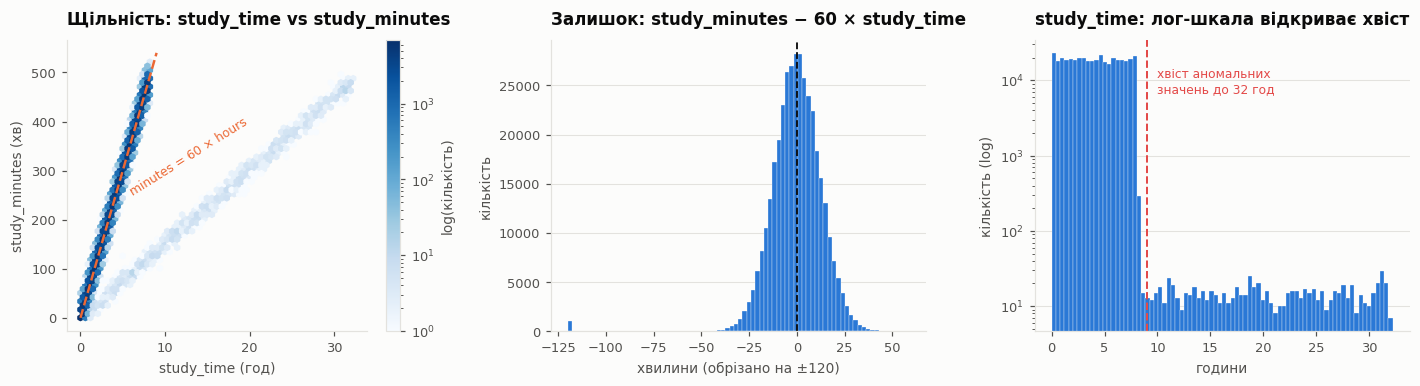

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.6))

# Щільність, а не scatter: 397k точок дали б чорну пляму без інформації
ax = axes[0]
hb = ax.hexbin(d.study_time, d.study_minutes, gridsize=55, cmap='Blues', mincnt=1, bins='log')
xs = np.linspace(0, 9, 10)
ax.plot(xs, 60 * xs, color=viz.ORANGE, linewidth=1.6, linestyle='--')
ax.text(5.6, 250, 'minutes = 60 × hours', fontsize=8, color=viz.ORANGE, rotation=32)
ax.set_title('Щільність: study_time vs study_minutes')
ax.set_xlabel('study_time (год)'); ax.set_ylabel('study_minutes (хв)')
ax.grid(False)
plt.colorbar(hb, ax=ax, label='log(кількість)')

ax = axes[1]
ax.hist(resid.clip(-120, 120), bins=80, color=viz.BLUE, edgecolor=viz.SURFACE, linewidth=0.2)
ax.axvline(0, color=viz.INK, linewidth=1.2, linestyle='--')
ax.set_title('Залишок: study_minutes − 60 × study_time')
ax.set_xlabel('хвилини (обрізано на ±120)'); ax.set_ylabel('кількість')

ax = axes[2]
ax.hist(train.study_time.dropna(), bins=80, color=viz.BLUE, edgecolor=viz.SURFACE, linewidth=0.2)
ax.axvline(9, color=viz.RED, linewidth=1.3, linestyle='--')
ax.set_yscale('log')
ax.text(10, ax.get_ylim()[1] * 0.2, 'хвіст аномальних\nзначень до 32 год',
        fontsize=8, color=viz.RED)
ax.set_title('study_time: лог-шкала відкриває хвіст')
ax.set_xlabel('години'); ax.set_ylabel('кількість (log)')

plt.tight_layout(); plt.show()

In [18]:
# Яка з двох версій сильніше пов'язана з таргетом — і чи різниця саме у викидах?
clean = train.study_time <= 9
tbl = pd.DataFrame({
    'Pearson з таргетом': [
        train.study_time.corr(train[C.TARGET]),
        train.loc[clean, 'study_time'].corr(train.loc[clean, C.TARGET]),
        train.study_minutes.corr(train[C.TARGET]),
    ],
    'Spearman з таргетом': [
        train.study_time.corr(train[C.TARGET], method='spearman'),
        train.loc[clean, 'study_time'].corr(train.loc[clean, C.TARGET], method='spearman'),
        train.study_minutes.corr(train[C.TARGET], method='spearman'),
    ],
}, index=['study_time (усі рядки)', 'study_time (тільки ≤ 9 год)', 'study_minutes']).round(4)
tbl

,Pearson з таргетом,Spearman з таргетом
study_time (усі рядки),0.7258,0.7675
study_time (тільки ≤ 9 год),0.7618,0.7692
study_minutes,0.7601,0.7677


### 6.1. Природа пошкодження: це не шум, а множник

Графік щільності вище показує **дві окремі смуги**, а не хмару з викидами. Друга смуга
має власний стабільний нахил — отже пошкодження систематичне. Якщо так, його можна
охарактеризувати точно: подивимось на відношення «справжні години / записані години»,
тобто `(study_minutes/60) / study_time`.

In [19]:

d2 = train.dropna(subset=['study_time', 'study_minutes'])
d2 = d2[d2.study_time > 0]
inv_ratio = d2.study_time / (d2.study_minutes / 60)      # у скільки разів study_time завищено

bad = d2[d2.study_time > 9.2]
inv_bad = bad.study_time / (bad.study_minutes / 60)

print(f'Серед {len(bad)} рядків зі study_time > 9.2 год:')
print(inv_bad.describe(percentiles=[.05, .25, .5, .75, .95]).round(4).to_string())
print(f'\nчастка в межах 4.0 ± 0.2: {(inv_bad.sub(4).abs() < 0.2).mean():.1%}')

# Якщо множник рівно 4, то study_time/4 має відновлювати години з точністю шуму вимірювання
rec, true_h = bad.study_time / 4, bad.study_minutes / 60
print(f'\nRMSE реконструкції study_time/4 проти study_minutes/60: '
      f'{np.sqrt(((rec - true_h) ** 2).mean()):.4f} год '
      f'(= {np.sqrt(((rec - true_h) ** 2).mean()) * 60:.1f} хв — порядок шуму вимірювання ±8 хв)')


Серед 804 рядків зі study_time > 9.2 год:
count    804.0000
mean       4.0046
std        0.1818
min        3.4172
5%         3.7196
25%        3.9000
50%        3.9991
75%        4.1047
95%        4.3059
max        4.7701

частка в межах 4.0 ± 0.2: 77.4%

RMSE реконструкції study_time/4 проти study_minutes/60: 0.1932 год (= 11.6 хв — порядок шуму вимірювання ±8 хв)


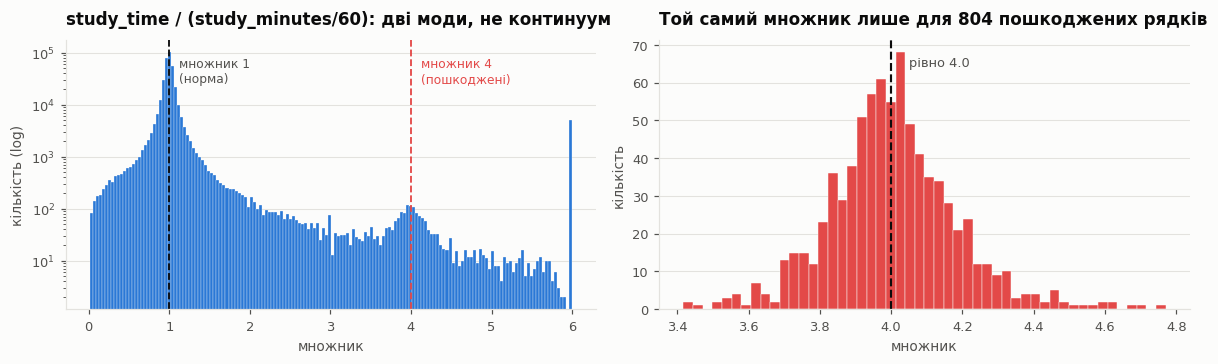

In [20]:

fig, axes = plt.subplots(1, 2, figsize=(11, 3.4))

ax = axes[0]
ax.hist(inv_ratio.clip(0, 6), bins=160, color=viz.BLUE, edgecolor=viz.SURFACE, linewidth=0.2)
ax.set_yscale('log')
for x, lab in [(1, 'множник 1\n(норма)'), (4, 'множник 4\n(пошкоджені)')]:
    ax.axvline(x, color=viz.RED if x == 4 else viz.INK, linewidth=1.2, linestyle='--')
    ax.text(x + 0.12, ax.get_ylim()[1] * 0.15, lab, fontsize=8,
            color=viz.RED if x == 4 else viz.INK_SECONDARY)
ax.set_title('study_time / (study_minutes/60): дві моди, не континуум')
ax.set_xlabel('множник'); ax.set_ylabel('кількість (log)')

ax = axes[1]
ax.hist(inv_bad, bins=50, color=viz.RED, edgecolor=viz.SURFACE, linewidth=0.3)
ax.axvline(4, color=viz.INK, linewidth=1.4, linestyle='--')
ax.text(4.05, ax.get_ylim()[1] * 0.9, 'рівно 4.0', fontsize=8.5, color=viz.INK_SECONDARY)
ax.set_title(f'Той самий множник лише для {len(bad)} пошкоджених рядків')
ax.set_xlabel('множник'); ax.set_ylabel('кількість')

plt.tight_layout(); plt.show()


**Висновок.** Читати ці дві панелі треба разом, і обережно.

**Ліва панель сама по собі нічого не доводить.** Основна маса справді на множнику 1.0,
на 4.0 є локальний горб — але між ними суцільний хвіст, а не порожнеча. Причина
механічна: відношення має `study_minutes` у знаменнику, і для рядків із малим часом
навчання (а `study_minutes` розподілений рівномірно від 0) шум вимірювання ±8 хв
роздувається у довільно великий множник. Тобто хвіст — це артефакт ділення, а не
свідчення пошкодження.

**Доказ дає права панель.** Якщо обмежитись рядками, де пошкодження однозначне
(`study_time` > 9.2 год — фізично неможливе значення), множник концентрується навколо
**4.0** дуже щільно: медіана 3.9991, середнє 4.0046, σ = 0.18, і 77% рядків у межах
4.0 ± 0.2. Такий розкид повністю пояснюється тим самим шумом ±8 хв. Якби пошкодження
було випадковим масштабуванням, ми бачили б широкий розподіл, а не пік.

Отже: **для частини рядків `study_time` помножено на 4.** Реконструкція `study_time / 4`
відновлює години з RMSE 0.19 год ≈ 11.6 хв — на рівні власного шуму вимірювання.

**Застереження про розмір ефекту.** 804 рядки — це ті пошкоджені, які видно, бо вони
перетнули поріг 9.2 год. Рядок із справжніми 1.5 год після множення на 4 дає 6 год —
фізично правдоподібно, і він залишиться непоміченим серед нормальних. Якщо справжні
години розподілені рівномірно на [0, 8.8], помітні лише ті, де справжнє значення
> 2.3 год, тобто близько 74% пошкоджених. Повна їх кількість — орієнтовно 1 100, і
решта розчинена в основній масі. Це аргумент на користь того, щоб у FE-1 брати
`study_minutes/60` як основне джерело годин **для всіх рядків**, а не виправляти лише
тих, хто перетнув поріг: поріг ловить не всі пошкодження.

Практичний наслідок: інформація не втрачена ніде, рядки не треба ні видаляти, ні
трактувати як пропуски. Це також пояснює, чому `study_minutes` ніде не перевищує
фізичну стелю 528 хв — пошкодження внесли тільки в колонку годин.

> ### ⚠️ Примітка, додана після ноутбука 03
>
> Рекомендація вище — брати `study_minutes/60` як джерело годин **для всіх рядків** —
> була протестована як варіант **FE-1d** і виявилась **хибною**:
>
> | варіант | XGBoost | Linear |
> |---|---:|---:|
> | 1b: ділити пошкоджені на 4 + взаємне заповнення | **8.9377** | **9.0200** |
> | 1d: хвилини як джерело для ВСІХ рядків | 8.9887 (**+0.033**) | 9.0886 |
>
> Помилка в міркуванні: `study_time` і `study_minutes` — **два незалежні виміри** однієї
> величини, кожен зі своїм шумом ±8 хв. Запис `study_time = study_minutes/60` робить
> колонки ідеально колінеарними й знищує другий вимір. Два шумні свідчення виявились
> ціннішими за одне «чисте».
>
> Прийнято варіант із порогом (FE-1b). Ті ~26% пошкоджених рядків, що не перетнули
> поріг 9.2 год, лишаються невиправленими — і це дешевше, ніж втратити другий вимір.
>
> Детально — §FE-1 ноутбука 03 і розділ 5.2 звіту.

**Висновок — це головна знахідка EDA.**

1. Кореляція між фічами 0.9485, медіана залишку `study_minutes − 60·study_time` рівно **0**,
   міжквартильний розмах ≈ ±8 хв. Отже це **одна й та сама величина**, виміряна двічі з
   невеликим шумом вимірювання.
2. Але `study_minutes` має чисту фізичну стелю 528 хв (8.80 год), а `study_time` тягнеться
   до 32.24 год — 849 рядків перевищують 9 год. На цих рядках `study_minutes` залишається
   правдоподібним: напр. `study_time` = 29.68 год при `study_minutes` = 445.4 хв = 7.42 год,
   або `study_time` = 31.68 при 481.0 хв = 8.02 год.
   **`study_time` містить ін'єктовані помилки масштабу; `study_minutes` — надійніша версія.**
   Це ж видно в розподілі залишку: мінімум −1452.5 хв (однобічний важкий хвіст), тоді як
   максимум лише +58.5 хв.
3. Підтвердження через кореляцію з таргетом:

   | версія | Pearson | Spearman |
   |---|---:|---:|
   | `study_time`, усі рядки | 0.7258 | 0.7675 |
   | `study_time`, тільки ≤ 9 год | **0.7618** | 0.7692 |
   | `study_minutes` | 0.7601 | 0.7677 |

   Зверни увагу на найпромовистіше: у `study_time` Pearson (0.7258) помітно нижчий за
   Spearman (0.7675), тоді як у `study_minutes` вони практично рівні. Spearman працює з
   рангами, тому **нечутливий до того, наскільки великий викид** — лише до його позиції.
   Pearson же псується саме величиною. Цей розрив між двома коефіцієнтами і є прямим
   відбитком помилок масштабу. Після очищення (≤ 9 год) Pearson підскакує до 0.7618 і
   розрив зникає.

4. Spearman ≈ Pearson для `study_minutes` також означає, що зв'язок із таргетом
   **монотонний і близький до лінійного**.

5. Природа пошкодження уточнена в §6.1: це **множник рівно 4**, а не випадковий шум.

**Рішення → експеримент FE-1 (ноутбук 03):**
- відновити години: `where(study_time > 9.2, study_time/4, study_time)` — еквівалентно
  `study_minutes/60`, але працює і тоді, коли `study_minutes` пропущений;
- консенсус двох вимірів після виправлення (усереднення знижує шум вимірювання);
- взаємне заповнення пропусків в обидва боки — це єдина зі змін, що реально
  **зменшує кількість пропусків**, а не просто переставляє числа.

Очікування: на деревах ефект малий (клампінг і масштабування монотонні, порядок рядків
майже не змінюється), на лінійній регресії помітний (викид у 32 год при σ = 2.5 —
це важіль). Це дає готове порівняння «та сама зміна фіч, два різні типи моделі»
з поясненням механізму, якого вимагає чекпоінт Feature Engineering.

## 7. Зв'язок фіч із таргетом: де сигнал, а де шум

Це розділ, який найбільше впливає на подальші рішення: він розділяє фічі на
корисні та марні й показує **форму** зв'язку, від якої залежить, яка модель тут
взагалі має перевагу.

In [21]:
corr = pd.DataFrame({
    'Pearson': train[C.NUM_COLS + [C.TARGET]].corr()[C.TARGET].drop(C.TARGET),
    'Spearman': train[C.NUM_COLS + [C.TARGET]].corr(method='spearman')[C.TARGET].drop(C.TARGET),
}).round(4).sort_values('Pearson', ascending=False)
corr

,Pearson,Spearman
study_minutes,0.7601,0.7677
engagement_index,0.7351,0.7341
study_time,0.7258,0.7675
attendance_rate,0.3586,0.3505
sleep_duration,0.1664,0.1590
learner_age,0.0109,0.0073
intake_marker,-0.0012,-0.0011


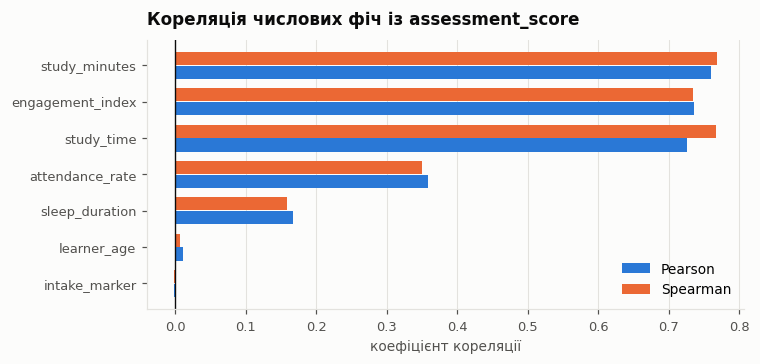

In [22]:
fig, ax = plt.subplots(figsize=(7, 3.4))
d = corr.sort_values('Pearson')
ypos = np.arange(len(d))
ax.barh(ypos - 0.19, d['Pearson'], height=0.36, color=viz.BLUE, label='Pearson')
ax.barh(ypos + 0.19, d['Spearman'], height=0.36, color=viz.ORANGE, label='Spearman')
ax.set_yticks(ypos); ax.set_yticklabels(d.index)
ax.axvline(0, color=viz.INK, linewidth=0.9)
ax.set_title('Кореляція числових фіч із assessment_score')
ax.set_xlabel('коефіцієнт кореляції')
ax.grid(axis='x'); ax.grid(axis='y', visible=False)
ax.legend(loc='lower right')
plt.tight_layout(); plt.show()

**Висновок.** Фічі різко розділяються на дві групи:

- **Сигнал:** `study_minutes` (0.760), `engagement_index` (0.735), `study_time` (0.726),
  `attendance_rate` (0.358), `sleep_duration` (0.167).
- **Шум:** `learner_age` (0.011), `intake_marker` (−0.001) — не відрізняються від нуля.

Pearson ≈ Spearman для всіх фіч означає, що зв'язки **монотонні та близькі до лінійних**.
Якби зв'язок був, скажімо, параболічним, Spearman помітно відрізнявся б від Pearson.
Це вже дає прогноз: нелінійні моделі отримають тут лише невелику перевагу над лінійною.

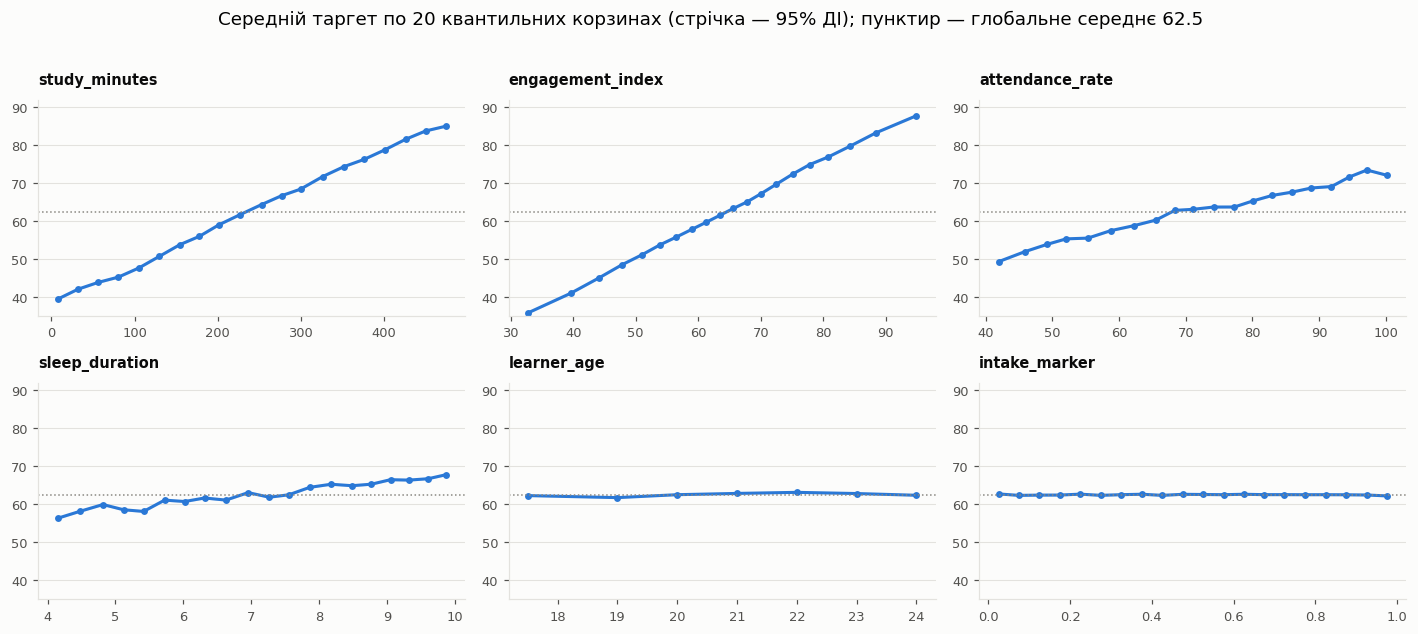

In [23]:
# Форма зв'язку: середній таргет по корзинах. Інформативніше за scatter на 397k точок.
signal_num = ['study_minutes', 'engagement_index', 'attendance_rate', 'sleep_duration',
              'learner_age', 'intake_marker']
fig, axes = plt.subplots(2, 3, figsize=(13, 5.6))
for ax, c in zip(axes.ravel(), signal_num):
    q = pd.qcut(train[c], q=20, duplicates='drop')
    g = train.groupby(q, observed=True).agg(m=(C.TARGET, 'mean'), n=(C.TARGET, 'size'),
                                            x=(c, 'mean'))
    se = train[C.TARGET].std() / np.sqrt(g.n)
    ax.plot(g.x, g.m, color=viz.BLUE, marker='o', markersize=3.5)
    ax.fill_between(g.x, g.m - 1.96 * se, g.m + 1.96 * se, color=viz.BLUE, alpha=0.18, linewidth=0)
    ax.axhline(train[C.TARGET].mean(), color=viz.INK_MUTED, linewidth=1.0, linestyle=':')
    ax.set_title(c, fontsize=9.5)
    ax.set_ylim(35, 92)
fig.suptitle('Середній таргет по 20 квантильних корзинах (стрічка — 95% ДІ); '
             'пунктир — глобальне середнє 62.5', y=1.02)
plt.tight_layout(); plt.show()

**Висновок — другий за важливістю результат EDA.**

- `study_minutes`: майже **ідеальна пряма** від 42 до 86 балів. Рівні кроки по всьому діапазону.
- `engagement_index`, `attendance_rate`, `sleep_duration`: також майже лінійні, монотонно зростаючі.
- `learner_age`, `intake_marker`: **плоскі лінії на рівні глобального середнього** — підтверджує,
  що це шум. Довірчі стрічки накривають пунктир по всій довжині.

**Наслідок для вибору моделі.** Таргет згенерований майже **адитивно** й майже лінійно.
Це означає:
1. Лінійна регресія забере майже весь сигнал — її RMSE буде недалеко від найкращого можливого.
2. Одиночне дерево, навпаки, у невигідному становищі: воно апроксимує пряму «сходинками»,
   і йому потрібно багато сплітів, щоб відтворити те, що лінійна модель бере одним коефіцієнтом.
   **Очікуємо, що дерево програє лінійній регресії** — це не помилка, а передбачуваний результат.
3. Приріст від градієнтного бустингу над лінійною моделлю буде скромним (одиниці десятих RMSE),
   бо нелінійності, яку він міг би спіймати, у даних мало.

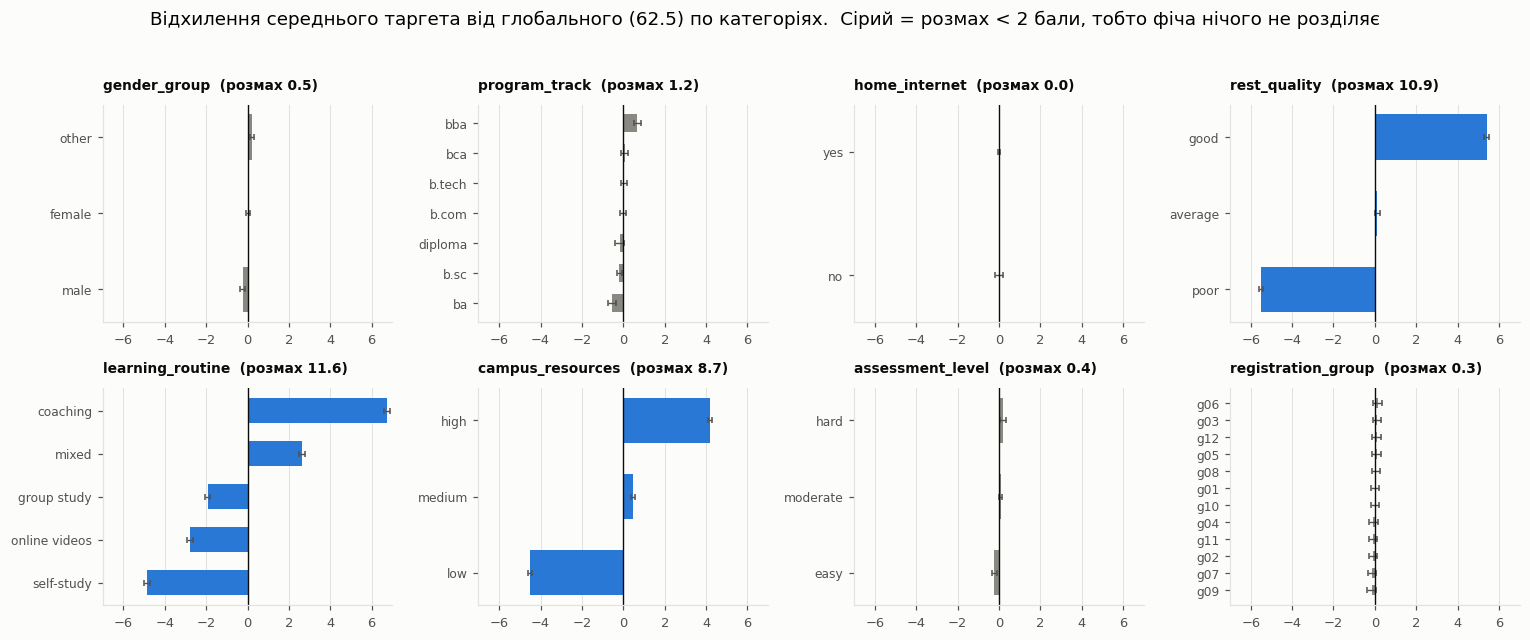

In [24]:
# Категоріальні фічі: середній таргет по групах із довірчими інтервалами
fig, axes = plt.subplots(2, 4, figsize=(14, 5.6))
gm = train[C.TARGET].mean()
for ax, c in zip(axes.ravel(), C.CAT_COLS):
    g = train.groupby(c, observed=True).agg(m=(C.TARGET, 'mean'), n=(C.TARGET, 'size')).sort_values('m')
    se = train[C.TARGET].std() / np.sqrt(g.n)
    spread = g.m.max() - g.m.min()
    colour = viz.BLUE if spread > 2 else viz.INK_MUTED     # сірий = ефект у межах шуму
    ax.barh(np.arange(len(g)), g.m - gm, xerr=1.96 * se, color=colour, height=0.6,
            error_kw=dict(ecolor=viz.INK_SECONDARY, lw=0.9, capsize=2))
    ax.set_yticks(np.arange(len(g))); ax.set_yticklabels(g.index, fontsize=8)
    ax.axvline(0, color=viz.INK, linewidth=0.9)
    ax.set_title(f'{c}  (розмах {spread:.1f})', fontsize=9)
    ax.set_xlim(-7, 7)
    ax.grid(axis='x'); ax.grid(axis='y', visible=False)
fig.suptitle('Відхилення середнього таргета від глобального (62.5) по категоріях.  '
             'Сірий = розмах < 2 бали, тобто фіча нічого не розділяє', y=1.03)
plt.tight_layout(); plt.show()

In [25]:
# Таблична форма того самого — щоб числа були в звіті, а не лише на графіку
rows = []
for c in C.CAT_COLS:
    g = train.groupby(c, observed=True)[C.TARGET].agg(['mean', 'size'])
    rows.append({'фіча': c, 'n_рівнів': len(g),
                 'min_серед': round(g['mean'].min(), 2),
                 'max_серед': round(g['mean'].max(), 2),
                 'розмах': round(g['mean'].max() - g['mean'].min(), 2),
                 'вердикт': 'СИГНАЛ' if g['mean'].max() - g['mean'].min() > 2 else 'шум'})
pd.DataFrame(rows).sort_values('розмах', ascending=False)

,фіча,n_рівнів,min_серед,max_серед,розмах,вердикт
4,learning_routine,5,57.66,69.26,11.60,СИГНАЛ
3,rest_quality,3,57.00,67.91,10.91,СИГНАЛ
5,campus_resources,3,58.00,66.72,8.72,СИГНАЛ
1,program_track,7,61.97,63.20,1.22,шум
0,gender_group,3,62.27,62.73,0.46,шум
6,assessment_level,3,62.28,62.70,0.42,шум
7,registration_group,12,62.36,62.65,0.29,шум
2,home_internet,2,62.51,62.51,0.00,шум


**Висновок.** Із восьми категоріальних фіч лише **три** несуть сигнал:

| фіча | розмах середніх | напрямок |
|---|---:|---|
| `learning_routine` | 11.60 | self-study 57.66 → coaching 69.26 |
| `rest_quality` | 10.91 | poor 57.00 → good 67.91 |
| `campus_resources` | 8.72 | low 58.00 → high 66.72 |

Решта п'ять мають розмах ≤ 1.22 бала при 32 000+ рядків на групу — це шум:
`program_track` 1.22, `gender_group` 0.46, `assessment_level` 0.42,
`registration_group` 0.29, `home_internet` 0.00.

Окремо варто відзначити `assessment_level`: попри назву («складність оцінювання»)
вона не пов'язана з балом, що контрінтуїтивно і варто згадати в звіті.
`registration_group` — 12 рівномірних адміністративних груп, класичний ідентифікатор
без змісту. `home_internet` дає розмах рівно 0.00 — найчистіший приклад мертвої фічі.

Зверни увагу: `rest_quality` і `campus_resources` — **впорядковані** категорії
(poor/average/good, low/medium/high). Для лінійної моделі їх можна закодувати одним
монотонним числом замість трьох one-hot колонок — кандидат для FE-4.

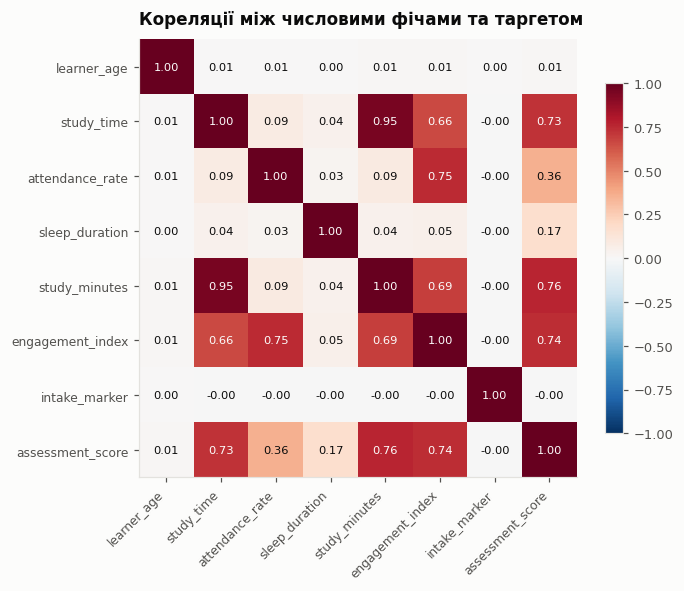

In [26]:
# Кореляційна матриця: шукаємо редундантність МІЖ фічами
fig, ax = plt.subplots(figsize=(6.6, 5.4))
cm = train[C.NUM_COLS + [C.TARGET]].corr()
im = ax.imshow(cm, cmap=viz.DIVERGING, vmin=-1, vmax=1)   # розбіжна: нейтральний центр у нулі
ax.set_xticks(range(len(cm))); ax.set_xticklabels(cm.columns, rotation=45, ha='right', fontsize=8)
ax.set_yticks(range(len(cm))); ax.set_yticklabels(cm.columns, fontsize=8)
for i in range(len(cm)):
    for j in range(len(cm)):
        v = cm.iloc[i, j]
        ax.text(j, i, f'{v:.2f}', ha='center', va='center', fontsize=7.5,
                color=viz.SURFACE if abs(v) > 0.55 else viz.INK)
ax.set_title('Кореляції між числовими фічами та таргетом')
ax.grid(False)
plt.colorbar(im, ax=ax, shrink=0.8)
plt.tight_layout(); plt.show()

**Висновок — тут матриця спростовує поверхневе враження.**

Сильних пар не одна, а чотири, і всі зав'язані на дві фічі:

| пара | r |
|---|---:|
| `study_time` ↔ `study_minutes` | 0.95 |
| `engagement_index` ↔ `attendance_rate` | 0.75 |
| `engagement_index` ↔ `study_minutes` | 0.69 |
| `engagement_index` ↔ `study_time` | 0.66 |

Перша пара вже розібрана в §6 — це одна величина у двох одиницях. Але `engagement_index`
корельований одразу з **трьома** іншими фічами, і при цьому не є копією жодної з них.
Схоже, це похідна величина. Перевіряємо в §7.1.

### 7.1. Чи `engagement_index` несе власну інформацію?

Якщо фіча є комбінацією інших, її висока кореляція з таргетом може бути **позиченою** —
вона корелює з таргетом лише тому, що корелює з фічами, які справді його визначають.

Перевірка у два кроки:
1. регресуємо `engagement_index` на решту числових фіч і дивимось R²;
2. беремо **залишок** цієї регресії (те, чого інші фічі не пояснюють) і міряємо його
   кореляцію з таргетом. Якщо вона близька до нуля — власної інформації у фічі немає.

In [27]:

from sklearn.linear_model import LinearRegression

others = [c for c in C.NUM_COLS if c != 'engagement_index']
d3 = train[C.NUM_COLS + [C.TARGET]].dropna()
Xo, ye = d3[others], d3['engagement_index']

lr = LinearRegression().fit(Xo, ye)
print(f'R² регресії engagement_index на решту числових фіч: {lr.score(Xo, ye):.4f}')
print('\nкоефіцієнти:')
print(pd.Series(lr.coef_, index=others).round(5).to_string())
print(f'intercept: {lr.intercept_:.4f}')

pair = ['study_minutes', 'attendance_rate']
print(f"\nR² лише на {pair}: {LinearRegression().fit(d3[pair], ye).score(d3[pair], ye):.4f}")

resid = ye - lr.predict(Xo)
print(f'\nσ залишку: {resid.std():.3f}   (вихідне σ engagement_index: {ye.std():.3f})')
print(f'кореляція ЗАЛИШКУ з таргетом:        {np.corrcoef(resid, d3[C.TARGET])[0, 1]:.4f}')
print(f'кореляція самого engagement з таргетом: {ye.corr(d3[C.TARGET]):.4f}')


R² регресії engagement_index на решту числових фіч: 0.9566

коефіцієнти:
learner_age        0.00029
study_time         0.26965
attendance_rate    0.64036
sleep_duration     0.00417
study_minutes      0.06805
intake_marker      0.02887
intercept: 0.6614

R² лише на ['study_minutes', 'attendance_rate']: 0.9565

σ залишку: 3.389   (вихідне σ engagement_index: 16.273)
кореляція ЗАЛИШКУ з таргетом:        0.0287
кореляція самого engagement з таргетом: 0.7355


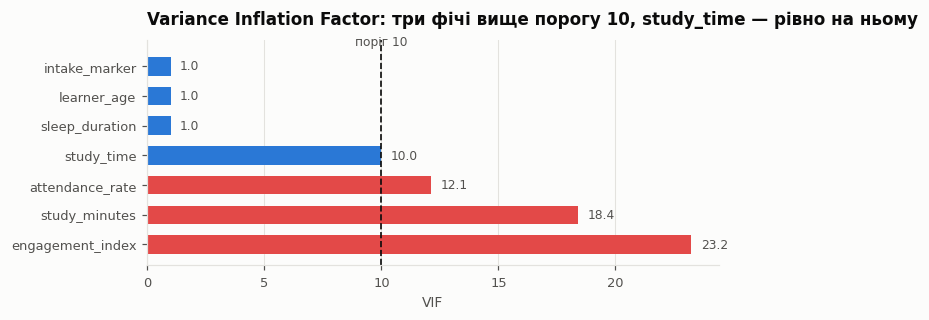

In [28]:

# VIF: наскільки кожна фіча передбачувана з решти. VIF = 1/(1-R²_i); VIF > 10 — тривожний поріг.
cc = np.linalg.inv(train[C.NUM_COLS].corr().values)
vif = pd.Series(np.diag(cc), index=C.NUM_COLS).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(6.8, 3.0))
colors = [viz.RED if v > 10 else viz.BLUE for v in vif.values]
ax.barh(vif.index, vif.values, color=colors, height=0.62)
ax.axvline(10, color=viz.INK, linewidth=1.1, linestyle='--')
ax.text(10, len(vif) - 0.3, 'поріг 10', fontsize=8, color=viz.INK_SECONDARY, ha='center')
for i, v in enumerate(vif.values):
    ax.text(v + 0.4, i, f'{v:.1f}', va='center', fontsize=8, color=viz.INK_SECONDARY)
ax.set_title('Variance Inflation Factor: три фічі вище порогу 10, study_time — рівно на ньому')
ax.set_xlabel('VIF')
ax.set_ylim(-0.7, len(vif) - 0.1)
ax.grid(axis='x'); ax.grid(axis='y', visible=False)
plt.tight_layout(); plt.show()


**Висновок — найважливіший для розділу «потенційно надлишкові фічі».**

`engagement_index` на **95.7%** пояснюється рештою числових фіч, і практично вся ця
передбачуваність тримається лише на двох із них: `study_minutes` + `attendance_rate`
дають R² = 0.9565 самі по собі. Відновлена формула близька до

```
engagement_index ≈ 0.66 + 0.64 × attendance_rate + 0.068 × study_minutes + 0.27 × study_time
```

тобто це **похідна композитна величина**, зважена суміш відвідуваності та часу навчання,
а не незалежний вимір.

Вирішальна перевірка — залишок. Кореляція самого `engagement_index` з таргетом 0.7355,
але кореляція його **залишку** (після вилучення того, що пояснюють інші фічі) — лише
**0.0287**. Отже сильний зв'язок із таргетом у цієї фічі **позичений**: вона корелює з
балом тому, що корелює з відвідуваністю й часом навчання, а власної інформації майже
не додає.

VIF підтверджує: `engagement_index` 23.2, `study_minutes` 18.4, `attendance_rate` 12.1 —
усі вище тривожного порогу 10; `study_time` рівно на порозі (10.0).

**Наслідки:**
1. **Для лінійної регресії це серйозна проблема.** При VIF = 23 коефіцієнт при
   `engagement_index` буде нестабільним, і інтерпретувати його окремо не можна. Це
   конкретне, виміряне обґрунтування обмеження лінійної моделі для чекпоінта Baseline —
   і пряма мотивація порівняти з Ridge, яка саме цю проблему й лікує.
2. **Для дерев проблема менша**, але надлишкова фіча «розмазує» важливість між
   корельованими колонками й робить permutation importance заниженою для кожної з них
   (перемішавши одну, модель компенсує іншою).
3. **Гіпотеза для FE-2:** видалення `engagement_index` має коштувати майже нічого.
   Це сильніший кандидат на прунінг, ніж очевидні шумові фічі, і набагато цікавіший:
   фіча з кореляцією 0.74 з таргетом, яку можна прибрати без втрат. Перевіряємо в ноутбуці 03.

> ### ⚠️ Примітка, додана після ноутбука 03
>
> Висновок «власної інформації майже не додає» виявився **хибним**. Видалення
> `engagement_index` (експеримент FE-2a) **погіршує** обидві моделі:
> XGBoost 8.9558 → 8.9794 (**+0.024**), LinearRegression 9.1954 → 9.2901 (**+0.095**).
>
> Причина методична: надлишковість тут виміряна на рядках **без жодного пропуску**.
> У реальному пайплайні 3% значень кожної числової фічі заповнені медіаною, і заповнене
> значення вже не містить інформації, з якої `engagement_index` можна відновити:
>
> | спосіб оцінки | R² | corr(залишок, таргет) |
> |---|---:|---:|
> | лише повні рядки (як тут) | 0.9566 | 0.029 |
> | з імпутацією (як у пайплайні) | 0.9332 | 0.085 |
>
> Коли `attendance_rate` або `study_minutes` пропущені, `engagement_index` лишається
> єдиним носієм цієї інформації для рядка. Його унікальний внесок — 0.72% дисперсії таргета.
>
> **Урок:** надлишковість, виміряна на повних рядках, завищує надлишковість у даних із
> пропусками. Коректна перевірка — прибрати фічу й поміряти.
>
> Детально — §FE-2 ноутбука 03 і розділ 5.3 звіту.

## 8. Пастка важливості фіч: кількість сплітів ≠ корисність

У §7 ми встановили, що `intake_marker` не пов'язаний із таргетом (r = −0.001).
Перевіримо, що покаже стандартна важливість фіч у градієнтному бустингу — і чому
на неї не можна покладатися.

Розрахунок на підвибірці 100k рядків, щоб не витрачати час: висновок якісний і
від розміру вибірки не залежить.

In [29]:
import lightgbm as lgb
from sklearn.inspection import permutation_importance
from sklearn.model_selection import train_test_split

sub = train.sample(100_000, random_state=C.SEED)
Xs, ys = sub[C.FEATURES_V0], sub[C.TARGET]
X_fit, X_val, y_fit, y_val = train_test_split(Xs, ys, test_size=0.25, random_state=C.SEED)

m = lgb.LGBMRegressor(n_estimators=400, learning_rate=0.05, num_leaves=63,
                      random_state=C.SEED, verbose=-1)
m.fit(X_fit, y_fit)

split_imp = pd.Series(m.feature_importances_, index=C.FEATURES_V0)

perm = permutation_importance(m, X_val, y_val, n_repeats=5, random_state=C.SEED,
                              scoring='neg_root_mean_squared_error', n_jobs=-1)
perm_imp = pd.Series(perm.importances_mean, index=C.FEATURES_V0)

imp = pd.DataFrame({
    'split_count': split_imp,
    'split_rank': split_imp.rank(ascending=False).astype(int),
    'permutation_ΔRMSE': perm_imp.round(4),
    'perm_rank': perm_imp.rank(ascending=False).astype(int),
}).sort_values('split_count', ascending=False)
imp

,split_count,split_rank,permutation_ΔRMSE,perm_rank
sleep_duration,3556,1,0.5448,8
attendance_rate,3260,2,0.9760,6
engagement_index,2883,3,1.1754,4
intake_marker,2721,4,-0.0090,15
study_minutes,2449,5,4.1161,1
study_time,2434,6,2.8759,2
registration_group,1507,7,0.0039,9
campus_resources,1141,8,0.9141,7
rest_quality,1088,9,1.3166,3
learner_age,1007,10,0.0031,10


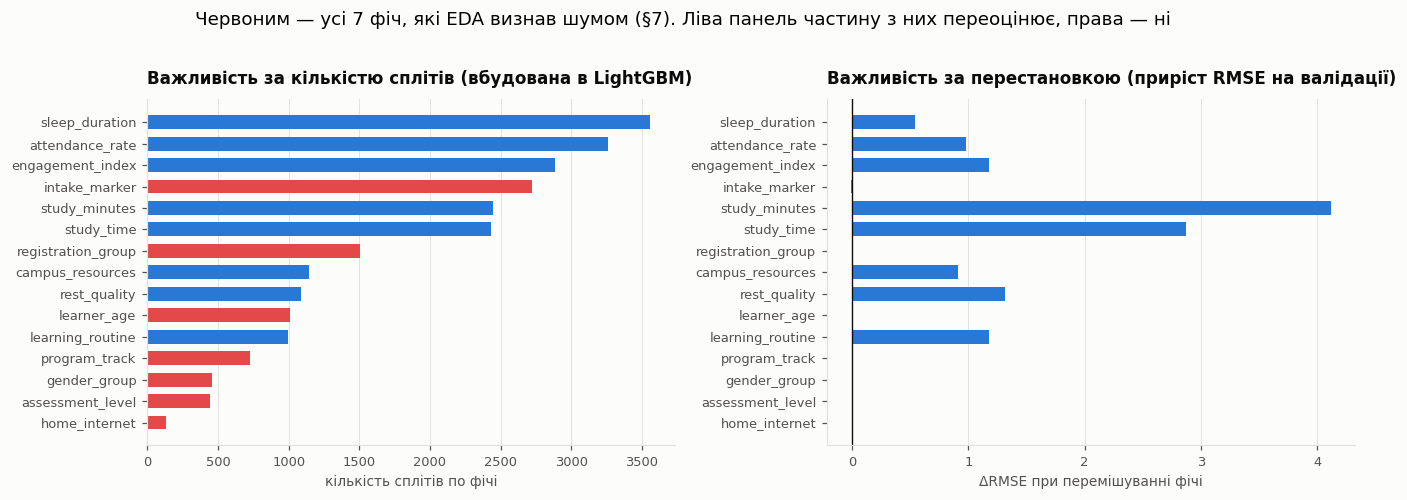

In [30]:
NOISE = ['intake_marker', 'learner_age', 'registration_group', 'gender_group',
         'program_track', 'assessment_level', 'home_internet']  # вердикт з §7

fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.4))

ax = axes[0]
d = split_imp.sort_values()
colors = [viz.RED if f in NOISE else viz.BLUE for f in d.index]
ax.barh(d.index, d.values, color=colors, height=0.65)
ax.set_title('Важливість за кількістю сплітів (вбудована в LightGBM)')
ax.set_xlabel('кількість сплітів по фічі')
ax.grid(axis='x'); ax.grid(axis='y', visible=False)

ax = axes[1]
d2 = perm_imp.reindex(d.index)
colors2 = [viz.RED if f in NOISE else viz.BLUE for f in d2.index]
ax.barh(d2.index, d2.values, color=colors2, height=0.65)
ax.axvline(0, color=viz.INK, linewidth=0.9)
ax.set_title('Важливість за перестановкою (приріст RMSE на валідації)')
ax.set_xlabel('ΔRMSE при перемішуванні фічі')
ax.grid(axis='x'); ax.grid(axis='y', visible=False)

fig.suptitle('Червоним — усі 7 фіч, які EDA визнав шумом (§7). '
             'Ліва панель частину з них переоцінює, права — ні', y=1.02)
plt.tight_layout(); plt.show()

**Висновок — важливий для звіту й захисту.**

Таблиця рангів розходиться різко. Два найпромовистіші випадки:

| фіча | ранг за сплітами | ранг за перестановкою | Δ RMSE |
|---|---:|---:|---:|
| `sleep_duration` | **1** | 8 | 0.54 |
| `intake_marker` | **4** | **15 (останній)** | **−0.009** |
| `study_minutes` | 5 | **1** | 4.12 |

`intake_marker` займає 4-те місце з 15 за кількістю сплітів (2 721 спліт), хоча його
кореляція з таргетом −0.0012, а важливість за перестановкою **від'ємна** (−0.009),
тобто перемішування цієї фічі навіть трохи **покращує** прогноз. Так само
`registration_group` (7-ме місце за сплітами) і `learner_age` (10-те) за перестановкою
дають ≈ 0.

Механізм: `intake_marker` — неперервна рівномірна змінна з 319 732 унікальними
значеннями (§1), тож вона пропонує майже нескінченну кількість можливих точок розрізу.
При жадібному пошуку дерево завжди знайде розріз, який випадково трохи зменшує MSE на
навчальних даних, і витратить на цю фічу спліт. `sleep_duration` страдає від того ж
ефекту в м'якшій формі: 634 унікальні значення дають багато варіантів розрізу, тому
фіча збирає найбільше сплітів, хоч її реальний внесок у 8 разів менший за `study_minutes`.

І навпаки, `study_minutes` — найкорисніша фіча за перестановкою (Δ RMSE 4.12) — за
кількістю сплітів лише 5-та: модель ловить її сигнал кількома точними розрізами й більше
до неї не повертається.

**Важливість за кількістю сплітів систематично переоцінює неперервні фічі з високою
кардинальністю і недооцінює фічі з сильним, але простим сигналом.** Правильний
інструмент — **permutation importance**, яка міряє, на скільки погіршиться якість на
**валідації**, якщо фічу перемішати.

Це підтверджує список фіч-кандидатів на видалення в експерименті FE-2.

## 9. Adversarial validation: чи відрізняється test від train?

Якщо між train і test є зсув розподілу, звичайний `KFold` дасть оптимістичну оцінку,
і потрібна була б інша схема валідації. Перевірка: навчити класифікатор відрізняти
train від test. Якщо ROC-AUC ≈ 0.5, набори нерозрізнювані.

In [31]:
from sklearn.model_selection import cross_val_score, StratifiedKFold

n = 60_000
a = train.sample(n, random_state=C.SEED)[C.FEATURES_V0].copy()
b = test.sample(n, random_state=C.SEED)[C.FEATURES_V0].copy()
Xa = pd.concat([a, b], ignore_index=True)
ya = np.r_[np.zeros(len(a)), np.ones(len(b))]

clf = lgb.LGBMClassifier(n_estimators=250, learning_rate=0.05, num_leaves=31,
                         random_state=C.SEED, verbose=-1)
auc = cross_val_score(clf, Xa, ya, cv=StratifiedKFold(3, shuffle=True, random_state=C.SEED),
                      scoring='roc_auc', n_jobs=-1)
print(f'ROC-AUC train vs test: {auc.mean():.4f} ± {auc.std():.4f}   (0.5 = нерозрізнювані)')

ROC-AUC train vs test: 0.5001 ± 0.0027   (0.5 = нерозрізнювані)


**Висновок.** AUC ≈ 0.50 — класифікатор не може відрізнити train від test.
Розподіли фіч ідентичні, зсуву немає.

**Рішення:** звичайний `KFold(n_splits=5, shuffle=True, random_state=42)` — коректна
схема валідації. Групування, стратифікація по таргету чи зважування під зсув не потрібні.

## 10. Висновки EDA → рішення в пайплайні

| # | Спостереження | Рішення |
|---|---|---|
| 1 | `program_track`, `rest_quality`, `learning_routine` містять категорії-двійники з пробілом і UPPERCASE (17 385 рядків). `learning_routine` показує гранично значущий зв'язок із таргетом (z = −2.46 проти порогу Бонферроні 2.39), але розмір ефекту лише 0.6 бала; агрегат по трьох колонках — шум (§4) | `strip` + `lower` у `src/data.py`, **до** CV: операція детермінована, витоку немає. Прапорець брудності в базовий фіче-сет не додаємо; зафіксовано як дешеву гіпотезу для ноутбука 03 з передбаченням нульового ефекту |
| 2 | Пропуски 2–3% у кожній фічі, MCAR: максимальний \|z\| різниці середніх 1.85 при 15 перевірках (очікувано ≈ 2.1 під нульовою гіпотезою); середнє й дисперсія кількості пропусків у рядку збігаються з незалежними індикаторами (§3) | Проста імпутація (median / most_frequent) **всередині фолду**. Прогноз: missing-індикатори не допоможуть → перевірка в **FE-3** |
| 3 | Структура пропусків у train і test ідентична (різниця ≤ 0.12 п.п.) (§1) | Імпутер, навчений на train, коректно переноситься на test |
| 4 | `study_time` і `study_minutes` — одна величина (r = 0.9485, медіана залишку 0). 804 видимі рядки пошкоджені множником 4 (медіана 3.9991, σ 0.18); поріг 9.2 год ловить лише ~74% пошкоджених, повна оцінка ≈ 1 100 (§6, §6.1) | **FE-1**: ділити пошкоджені на 4 (варіант із порогом). Рекомендація «брати хвилини для всіх рядків» протестована як FE-1d і **відхилена** — вона знищує другий незалежний вимір, +0.033 на XGBoost. Плюс взаємне заповнення пропусків. Інформація не втрачена — рядки не видаляти |
| 5 | Порушення фізичних меж: `engagement_index` > 100 (1 328), `study_time` > 9 (849), `attendance_rate` > 100 (682) (§5) | Клампінг до меж із домену (не з даних → не навчена операція). Очікування: нуль для дерев, помітний ефект для лінійної моделі |
| 6 | Шумові фічі: `intake_marker` (r = −0.0012), `learner_age` (r = 0.0109) та `program_track` (розмах 1.22), `gender_group` (0.46), `assessment_level` (0.42), `registration_group` (0.29), `home_internet` (0.00) (§7) | **FE-2**: поетапний прунінг — спершу `intake_marker` і `registration_group`, потім решта |
| 7 | Сигнальні фічі: `study_minutes` (0.760), `engagement_index` (0.735, але похідна — див. п.9), `study_time` (0.726), `attendance_rate` (0.359), `sleep_duration` (0.166) + `learning_routine` (11.60), `rest_quality` (10.91), `campus_resources` (8.72) (§7) | Ядро базового фіче-сету v0. Незалежних вимірів насправді менше, ніж фіч: час навчання, відвідуваність, сон і три категорії |
| 8 | Зв'язки з таргетом майже **лінійні**: Pearson ≈ Spearman для всіх фіч, рівні кроки середнього по 20 квантильних корзинах (§7) | Прогноз: лінійна регресія близька до оптимуму; **дерево має програти лінійній**; приріст бустингу скромний. Перевірка — ноутбук 02 |
| 9 | **Сильна мультиколінеарність:** VIF `engagement_index` 23.2, `study_minutes` 18.4, `attendance_rate` 12.1, `study_time` 10.0. На повних рядках фіча виглядає на 95.7% похідною (corr залишку з таргетом 0.029) (§7.1) | Обґрунтування обмеження лінійної регресії та мотивація Ridge. **FE-2a перевірив видалення — і воно ПОГІРШУЄ** (+0.024 XGBoost, +0.095 Linear): з імпутацією фіча менш надлишкова (R² 0.933, corr залишку 0.085) і несе 0.72% дисперсії таргета. Фіча залишена |
| 10 | `sleep_duration` — 1-ше місце за кількістю сплітів, 8-ме за перестановкою; `intake_marker` — 4-те за сплітами, останнє (від'ємне) за перестановкою (§8) | Для відбору фіч використовувати **permutation importance**, не вбудовану важливість |
| 11 | `rest_quality`, `campus_resources` — впорядковані категорії; `learner_age` має лише 8 рівнів (§1, §7) | **FE-4**: порядкове кодування одним числом замість трьох one-hot колонок (передусім для лінійної моделі) |
| 12 | Таргет **цензурований**: точкові маси рівно на 100.0 (2.46%) і рівно на 19.599 (1.00%), разом 3.46%; skew −0.049 (§2) | Трансформація таргета не потрібна. Клампінг прогнозів у **[19.599, 100.0]** — спостережені межі train, не [0, 100]: сабмішн кроку 0 дав 92 прогнози нижче підлоги. Цензурування ставить стелю на досяжний RMSE. Константний базлайн = 18.9183 |
| 13 | Adversarial AUC = 0.5001 ± 0.0027 — зсуву train/test немає (§9) | `KFold(5, shuffle=True, random_state=42)` — коректна схема |

### Методична примітка
Перша версія перевірки «брудності» (§4) використовувала наївний критерій і дала
фальшивий значущий результат, бо позначила канонічний формат `registration_group`
(`G01`…`G12`) як помилку. Це зафіксовано в §4 як приклад того, чому автоматичну
перевірку треба зіставляти зі змістом даних.

### Що далі
`02_benchmarks.ipynb` — константний базлайн, лінійна регресія, дерево, ліс, XGBoost
на спільних фолдах і спільному фіче-сеті v0.